In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [80]:
data1=pd.read_csv(r"C:\Users\rajiv\Downloads\Telco-Customer-Churn.csv")
data1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [81]:
# Checking the information about the dataset

data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [82]:
data1["TotalCharges"]=pd.to_numeric(data1["TotalCharges"],errors="coerce")

In [83]:
data1["TotalCharges"].dtype

dtype('float64')

In [85]:
data1.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [89]:
# Check the duplicated values

data1.duplicated().sum()

np.int64(0)

In [92]:
# Check the missing Values

data1.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [94]:
data1["TotalCharges"] = data1["TotalCharges"].fillna(data1["TotalCharges"].mean())

In [96]:
data1.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

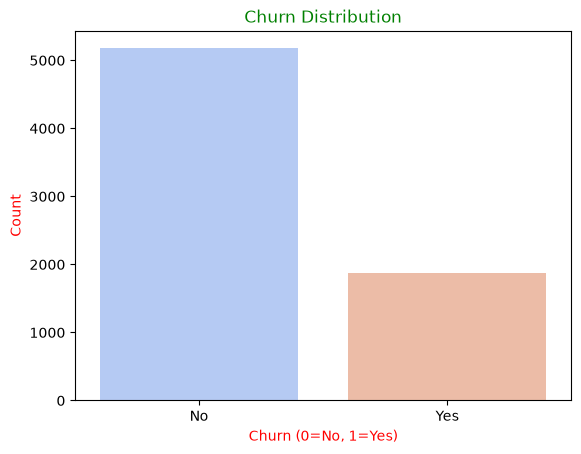

In [99]:
# Visualization

sns.countplot(x="Churn", data=data1,palette="coolwarm")
plt.title("Churn Distribution",color="Green")
plt.xlabel("Churn (0=No, 1=Yes)",color="Red")
plt.ylabel("Count",color="Red")
plt.show()

<Axes: >

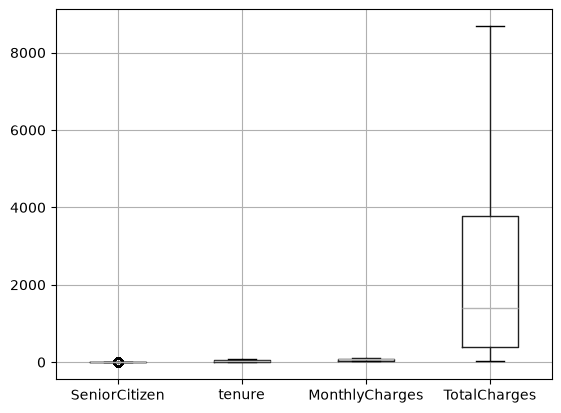

In [100]:
# Outliers chekcing

data1.boxplot()

In [101]:
# Outliers capping

# ===== STEP 1: Outlier Capping (only on continuous columns) =====
def outliers_capping(data1, column):
    Q1 = data1[column].quantile(0.25)
    Q3 = data1[column].quantile(0.75)
    IQR = Q3 - Q1
    Lower_extreme = Q1 - 1.5 * IQR
    Upper_extreme = Q3 + 1.5 * IQR
    data1[column] = data1[column].apply(
        lambda x: Lower_extreme if x < Lower_extreme else Upper_extreme if x > Upper_extreme else x
    )

# Only apply to genuinely continuous columns — NOT all numeric columns
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    outliers_capping(data1, col)

<Axes: >

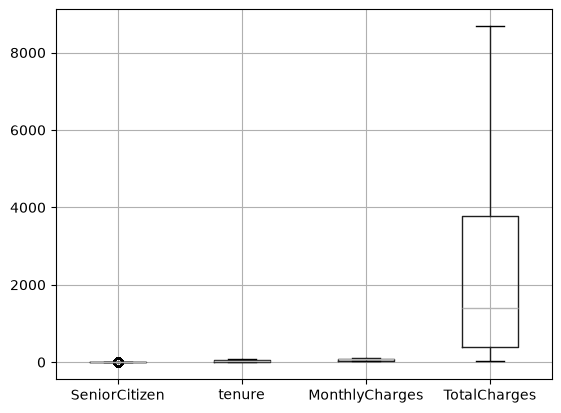

In [102]:
data1.boxplot()

In [103]:
# Handelling the Categorical columns for the further process

cat_cols= data1.select_dtypes(include="object").columns

In [105]:
cat_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [106]:
# We should treat these categorical column by encoding them correctly

In [113]:
# Import Package

from sklearn.preprocessing import LabelEncoder

lable=LabelEncoder()

# Encoding all the categorical column

for col in cat_cols:
    data1[col]=lable.fit_transform(data1[col])

In [115]:
# Target & Features split

target= data1[["Churn"]]
features= data1.drop(["customerID","Churn"],axis=1)

In [117]:
features.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


In [119]:
target.head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [121]:
# Importing the packages

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 19)
(1409, 19)
(5634, 1)
(1409, 1)


In [123]:
# Importing the packages

from sklearn.preprocessing import StandardScaler
std_sca=StandardScaler()

x_train=pd.DataFrame(std_sca.fit_transform(x_train),columns=x_train.columns,index=x_train.index)
x_test=pd.DataFrame(std_sca.transform(x_test),columns=x_test.columns,index=x_test.index)

In [125]:
x_train = x_train.reset_index(drop=True)
x_test = x_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [126]:
x_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1.000355,-0.439475,1.043546,-0.661522,0.472016,-3.071373,0.068855,-1.184657,-0.928180,1.231596,1.237471,-0.937904,1.145090,1.136975,1.556943,-1.201770,-1.472176,-0.338701,0.048302
1,-0.999645,-0.439475,-0.958271,-0.661522,-0.219704,0.325587,1.123014,0.162337,-0.928180,-1.046412,-1.041677,-0.937904,1.145090,1.136975,-0.835806,0.832106,-1.472176,1.030607,0.138969
2,-0.999645,-0.439475,-0.958271,-0.661522,-1.236939,0.325587,-0.985304,0.162337,-0.928180,-1.046412,-1.041677,-0.937904,-1.123348,-1.131338,-0.835806,-1.201770,0.399057,0.147022,-0.956965
3,-0.999645,-0.439475,1.043546,-0.661522,-1.236939,0.325587,-0.985304,1.509332,0.237528,0.092592,0.097897,0.224470,0.010871,0.002818,-0.835806,-1.201770,1.334673,-1.464319,-0.991452
4,1.000355,2.275441,-0.958271,-0.661522,-0.830045,0.325587,-0.985304,0.162337,-0.928180,1.231596,1.237471,1.386844,-1.123348,-1.131338,-0.835806,0.832106,1.334673,0.639376,-0.554097


In [127]:
# Model Building

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
log_model=LogisticRegression()

# Model Training

log_model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [128]:
# Prediction

y_pred_train=log_model.predict(x_train)
y_pred_test=log_model.predict(x_test)

# printing the train and test accuracy 

print("Training Prediction:",y_pred_train)
print("Testing Prediction:",y_pred_test)

Training Prediction: [0 1 1 ... 0 1 1]
Testing Prediction: [0 0 0 ... 0 0 0]


In [129]:
# Checking the accuracy score

print("Train Accuracy:",accuracy_score(y_train,y_pred_train))
print("Test Accuracy:",accuracy_score(y_test,y_pred_test))

Train Accuracy: 0.8086616968406106
Test Accuracy: 0.78708303761533


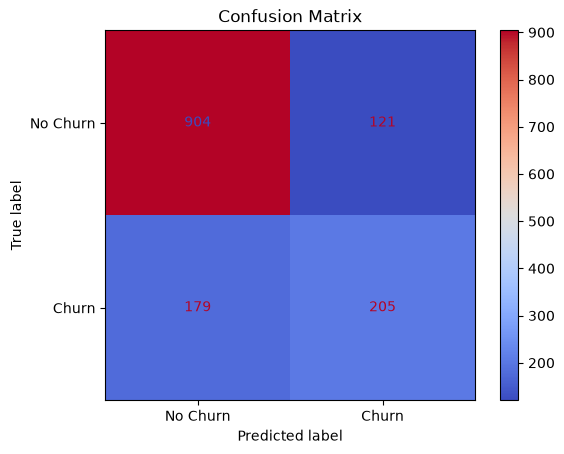

In [130]:
# Confusion Matrix & Confusion Matrix Display

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="coolwarm")
plt.title('Confusion Matrix')
plt.show()

In [138]:
# Model Deployment

# =========================================================
# ADD THIS CODE TO THE END OF YOUR NOTEBOOK (after Cell 41)
# It saves everything your app will need: the model, the
# scaler, the encoders, and the exact order of feature columns.
# =========================================================

import joblib

# -----------------------------------------------------------
# STEP 1: Save the label encoders while you fit them
# -----------------------------------------------------------
# In your notebook, Cell 25 currently looks like this:
#
#   for col in cat_cols:
#       data1[col] = lable.fit_transform(data1[col])
#
# The problem: this only keeps the LAST column's encoder in
# memory (because you reuse the same "lable" variable each
# loop). We need a SEPARATE encoder saved for EACH column,
# so replace Cell 25 with this instead:

from sklearn.preprocessing import LabelEncoder

encoders = {}  # this dictionary will store one encoder per column

for col in cat_cols:
    le = LabelEncoder()
    data1[col] = le.fit_transform(data1[col])
    encoders[col] = le  # save this column's encoder for later use

# -----------------------------------------------------------
# STEP 2: After training your model (Cell 37), save everything
# -----------------------------------------------------------

# Save the trained Logistic Regression model
joblib.dump(log_model, "churn_model.pkl")

# Save the StandardScaler (needed to scale new user input the
# same way your training data was scaled)
joblib.dump(std_sca, "scaler.pkl")

# Save the dictionary of LabelEncoders (needed to convert new
# user input like "Yes"/"No" into the numbers the model expects)
joblib.dump(encoders, "encoders.pkl")

# Save the exact list and order of feature columns
# (the model expects columns in this exact order every time)
joblib.dump(list(features.columns), "feature_columns.pkl")

print("Saved: churn_model.pkl, scaler.pkl, encoders.pkl, feature_columns.pkl")

# -----------------------------------------------------------
# After running this, you will have 4 new files sitting in the
# same folder as your notebook. Copy all 4 into the same folder
# as app.py before running the Streamlit app.
# -----------------------------------------------------------

Saved: churn_model.pkl, scaler.pkl, encoders.pkl, feature_columns.pkl
